<a href="https://colab.research.google.com/github/ha486-gk/DeepLearning/blob/main/RL_Blackjack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RL- Blackjack

In [2]:
# 1. 라이브러리 설치 (매번 실행 필요)
!pip install gymnasium[toy_text]

import os
import numpy as np
import gymnasium as gym

# 2. 드라이브 내 프로젝트 폴더 설정 (수동 마운트 후 실행)
# 'MyDrive' 뒤의 경로는 본인이 구글 드라이브에 만든 폴더 이름으로 수정하세요.
MY_PATH = '/content/drive/MyDrive/RL_Project/Blackjack/'

# 폴더가 없으면 자동으로 만들어주는 안전 장치
if not os.path.exists(MY_PATH):
    os.makedirs(MY_PATH)
    print(f"새 폴더를 생성했습니다: {MY_PATH}")
else:
    print(f"기존 폴더를 연결했습니다: {MY_PATH}")

기존 폴더를 연결했습니다: /content/drive/MyDrive/RL_Project/Blackjack/


환경 구성

In [3]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
# dict의 default class를 지정해준다. 지정되지 않은 key의 값을 초기화한다.
# defaultdict(int) 이면 키의 초깃값이 0으로 지정, list이면 [] 등으로 초기화됨. 이후 키의 값을 다른 class로 변경 가능

env = gym.make('Blackjack-v1')

MC ES

In [30]:
# 1. Q-Table 생성 (상태별 행동의 가치를 저장할 딕셔너리)
# 상태 예시: (내 점수, 딜러 점수, 에이스 유무)
Q = defaultdict(lambda: np.zeros(env.action_space.n)) # lambda는 익명의 0행렬 객체를 호출해주는 익명 함수
# key = state, value = [Hit가치, Stand 가치]
C = defaultdict(lambda: np.zeros(env.action_space.n)) # 상태-행동쌍 방문횟수, 점증적 구현을 위함.
# policy 변수의 필요성 부재
# why? 이 문제의 경우 Q의 argmax 인덱스 값이 바로 policy랑 같은 의미이기 때문

# 시작 탐험 가정
def get_action_exploring_starts(state):
  return env.action_space.sample() # Hit(0), Stand(1) 둘 중 무작위 추출

def get_action(state):
  return np.argmax(Q[state]) # argmax는 max값의 인덱스를 반환

# 2. 에피소드 만들기 - episodic task
def get_episode():
  episode = []
  state, info = env.reset()
  action = get_action_exploring_starts(state)
  while True:
      next_state, reward, terminated, truncated, info = env.step(action)
      episode.append((state, action, reward))
      if terminated or truncated:
          break
      state = next_state
      action = get_action(state)
  return episode

# 3. 학습

epoch = 100000

for i in range(epoch):
  episode = get_episode()
  states, actions, rewards = zip(*episode) # state, action, rewards 모두 각각 튜플로 저장됨
  Gt = 0

  for t in range(len(states)-2,-1,-1):
    Gt = Gt+ rewards[t+1]
    visit_before = False
    for j in range(t):
      if states[j] == states[t] and actions[j] == actions[t]:
        visit_before = True
        break
    if not visit_before:
      C[states[t]][actions[t]] += 1
      Q[states[t]][actions[t]] += (Gt - Q[states[t]][actions[t]]) / C[states[t]][actions[t]] # 점증적 구현

print(f"{epoch}회 학습이 수행되었습니다.")

# 여기서 수익(Return)을 계산하여 Q 테이블을 업데이트합니다.

100000회 학습이 수행되었습니다.


### 학습 과정 모니터링


==================== Episode 1000 Checkpoint ====================


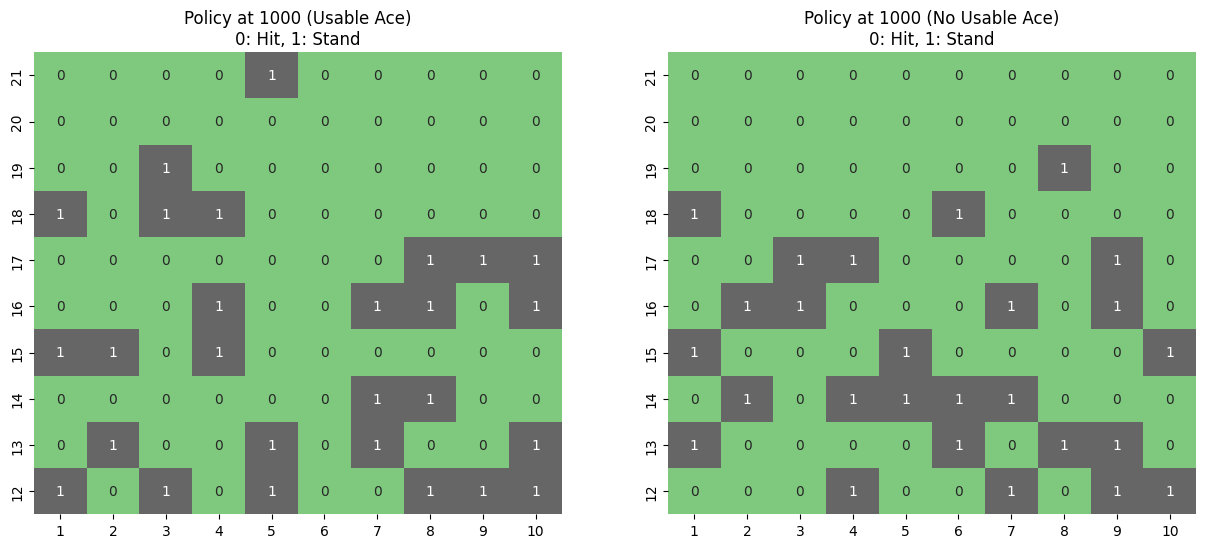


==================== Episode 5000 Checkpoint ====================


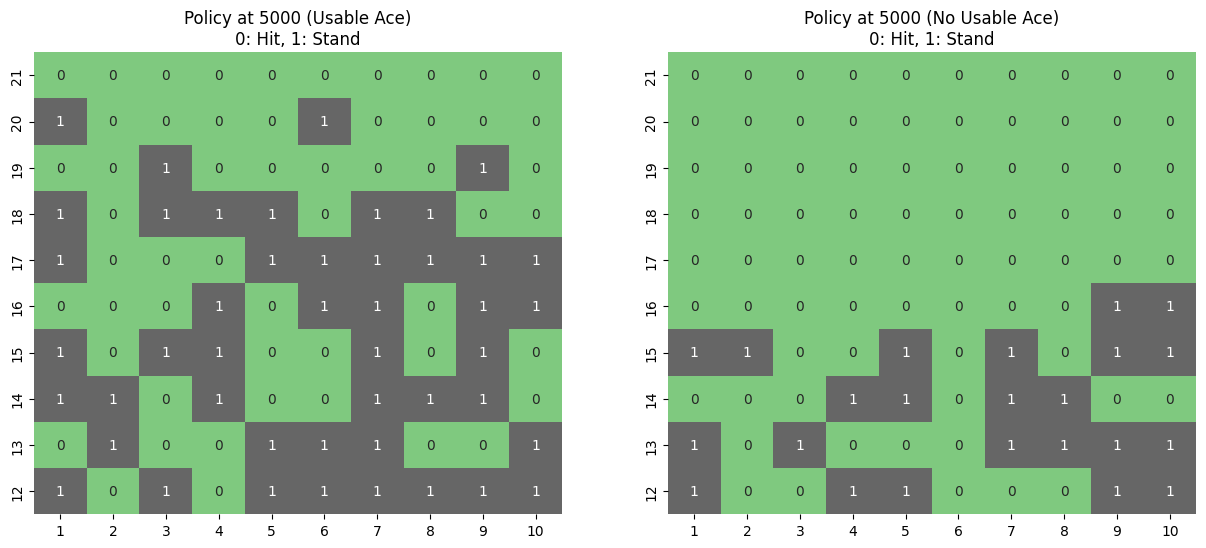


==================== Episode 50000 Checkpoint ====================


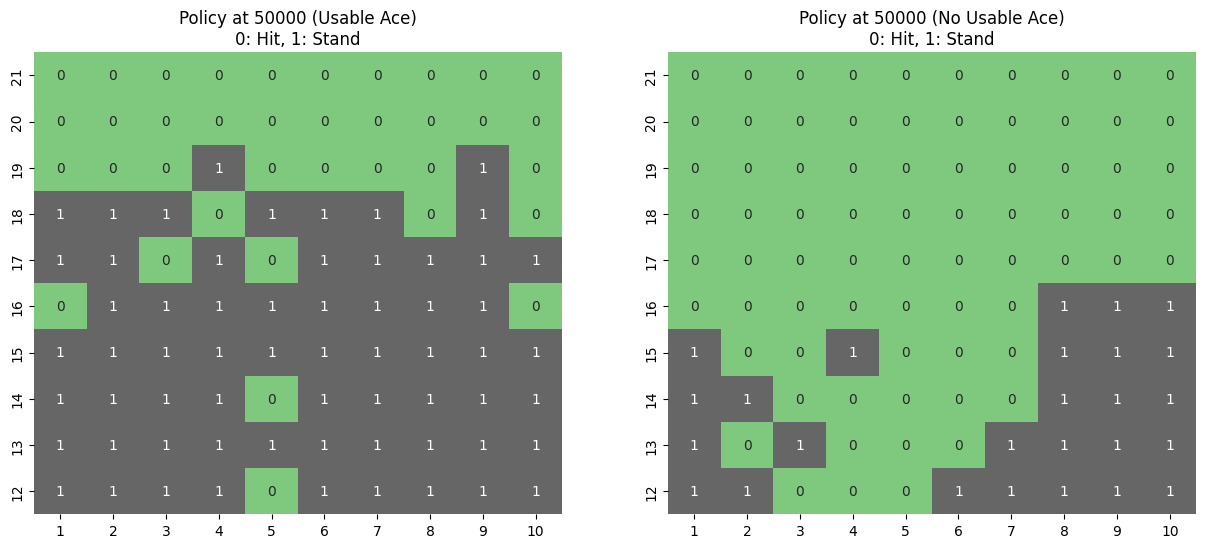


==================== Episode 100000 Checkpoint ====================


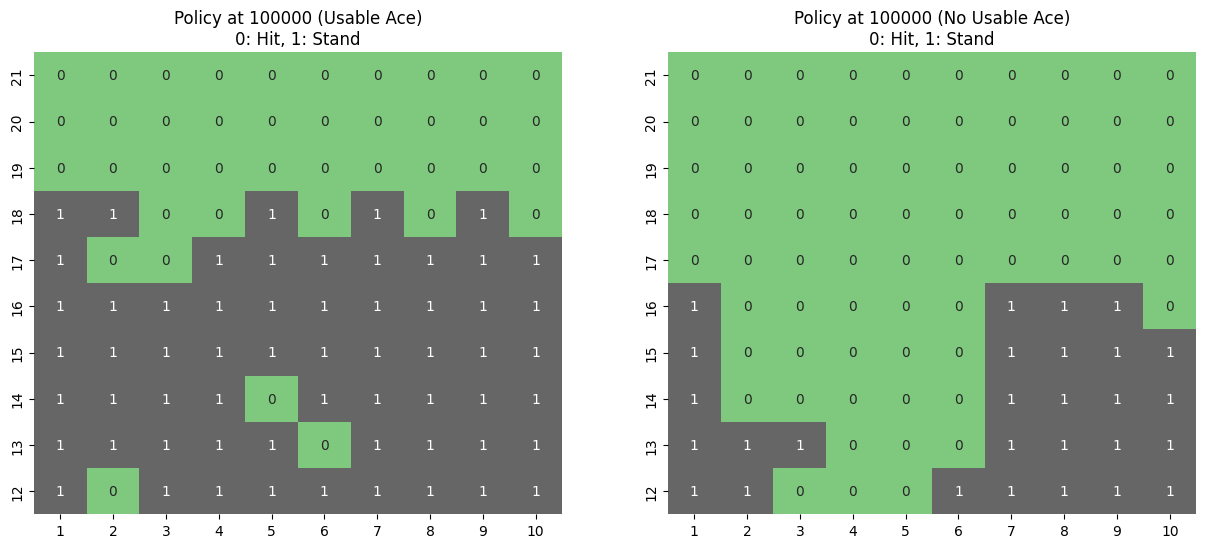


학습 및 모니터링이 완료되었습니다.


In [31]:

# 초기화
Q = defaultdict(lambda: np.zeros(env.action_space.n))
C = defaultdict(lambda: np.zeros(env.action_space.n))
history = {}
checkpoints = [1000, 5000, 50000, 100000]

for i in range(1, max(checkpoints) + 1):
    episode = get_episode()
    states, actions, rewards = zip(*episode)
    Gt = 0
    for t in range(len(states)-1, -1, -1):
        Gt += rewards[t]
        visited_before = False
        for j in range(t):
            if states[j] == states[t] and actions[j] == actions[t]:
                visited_before = True
                break
        if not visited_before:
            C[states[t]][actions[t]] += 1
            Q[states[t]][actions[t]] += (Gt - Q[states[t]][actions[t]]) / C[states[t]][actions[t]]

    if i in checkpoints:
        print(f"\n{'='*20} Episode {i} Checkpoint {'='*20}")
        # 현재 상태 시각화
        plot_policy(Q, f"Policy at {i}")
        # history에 복사본 저장 (나중에 다시 보기 위함)
        history[i] = {k: v.copy() for k, v in Q.items()}

print("\n학습 및 모니터링이 완료되었습니다.")


### 정책 평가 (Win Rate Test)
학습된 정책이 실제로 얼마나 이기는지 확인해봅시다. (1000판 기준)

In [26]:

def evaluate_policy(Q, n_episodes=1000):
    wins = 0
    draws = 0
    losses = 0

    for _ in range(n_episodes):
        state, info = env.reset()
        terminated = False
        truncated = False

        while not (terminated or truncated):
            # 학습된 Q-table에 따라 최선의 행동 선택
            action = np.argmax(Q.get(state, [0, 0]))
            state, reward, terminated, truncated, info = env.step(action)

        if reward > 0:
            wins += 1
        elif reward == 0:
            draws += 1
        else:
            losses += 1

    print(f"테스트 결과 ({n_episodes}판):")
    print(f"승리: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"무승부: {draws} ({draws/n_episodes*100:.1f}%)")
    print(f"패배: {losses} ({losses/n_episodes*100:.1f}%)")



In [28]:

# 학습된 Q-table을 사용하여 정책 평가 수행
evaluate_policy(Q, n_episodes=1000)


테스트 결과 (1000판):
승리: 422 (42.2%)
무승부: 87 (8.7%)
패배: 491 (49.1%)


### 상태별 방문 횟수(C) 시각화
특정 상태가 얼마나 자주 탐험되었는지 확인하여 학습의 신뢰도를 평가합니다.

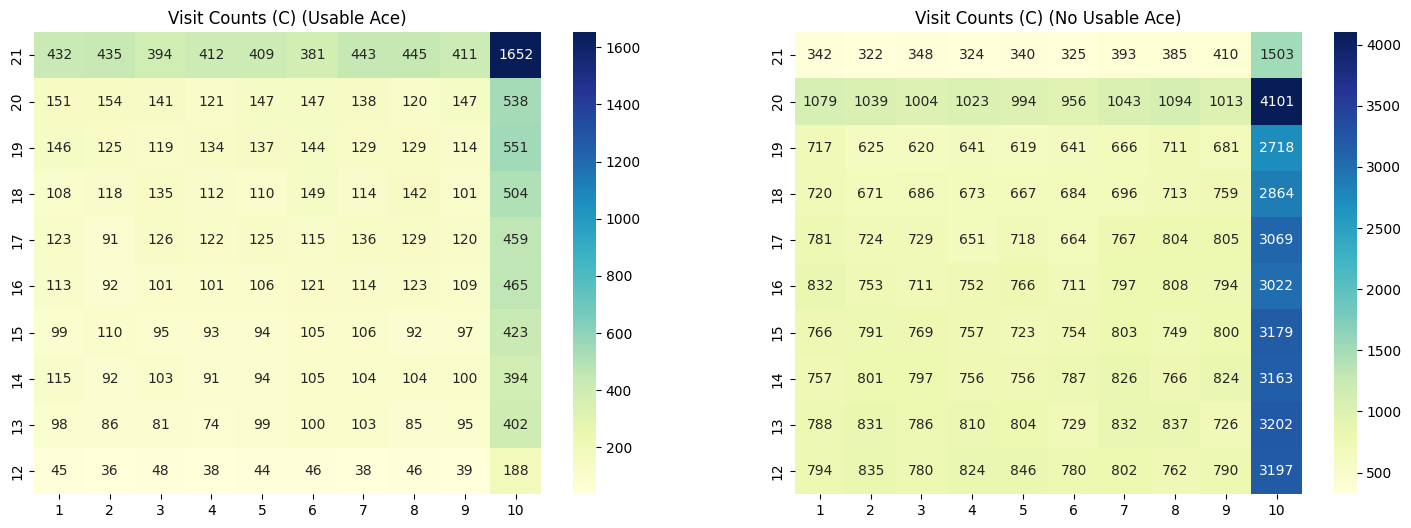

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_visit_counts(C, title="Visit Counts (C)"):
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)

    # 방문 횟수의 합산 (Hit/Stand 합계)
    C_ace = np.zeros((len(player_range), len(dealer_range)))
    C_no_ace = np.zeros((len(player_range), len(dealer_range)))

    for i, p in enumerate(player_range):
        for j, d in enumerate(dealer_range):
            C_ace[i, j] = np.sum(C.get((p, d, True), [0, 0]))
            C_no_ace[i, j] = np.sum(C.get((p, d, False), [0, 0]))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Usable Ace Heatmap
    sns.heatmap(C_ace, xticklabels=dealer_range, yticklabels=player_range,
                ax=axes[0], annot=True, fmt='.0f', cmap='YlGnBu')
    axes[0].set_title(f'{title} (Usable Ace)')
    axes[0].invert_yaxis()

    # No Usable Ace Heatmap
    sns.heatmap(C_no_ace, xticklabels=dealer_range, yticklabels=player_range,
                ax=axes[1], annot=True, fmt='.0f', cmap='YlGnBu')
    axes[1].set_title(f'{title} (No Usable Ace)')
    axes[1].invert_yaxis()

    plt.show()

# 방문 횟수 시각화 실행
plot_visit_counts(C)